In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

%matplotlib inline

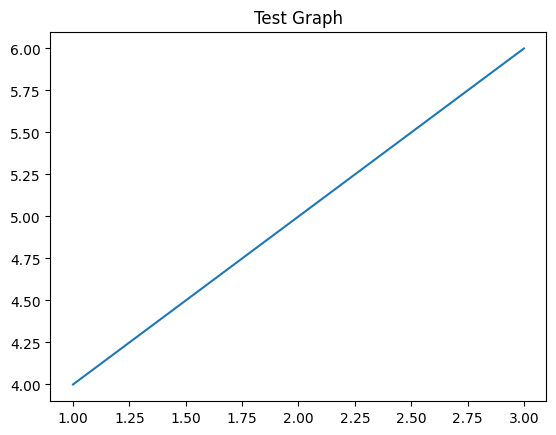

In [18]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3], [4, 5, 6])
plt.title("Test Graph")
plt.show()


In [19]:
import pandas as pd


In [20]:
dia_df = pd.read_csv("diabetes.csv")

In [21]:
dia_df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [22]:
dia_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [23]:
dia_df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [24]:
dia_df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


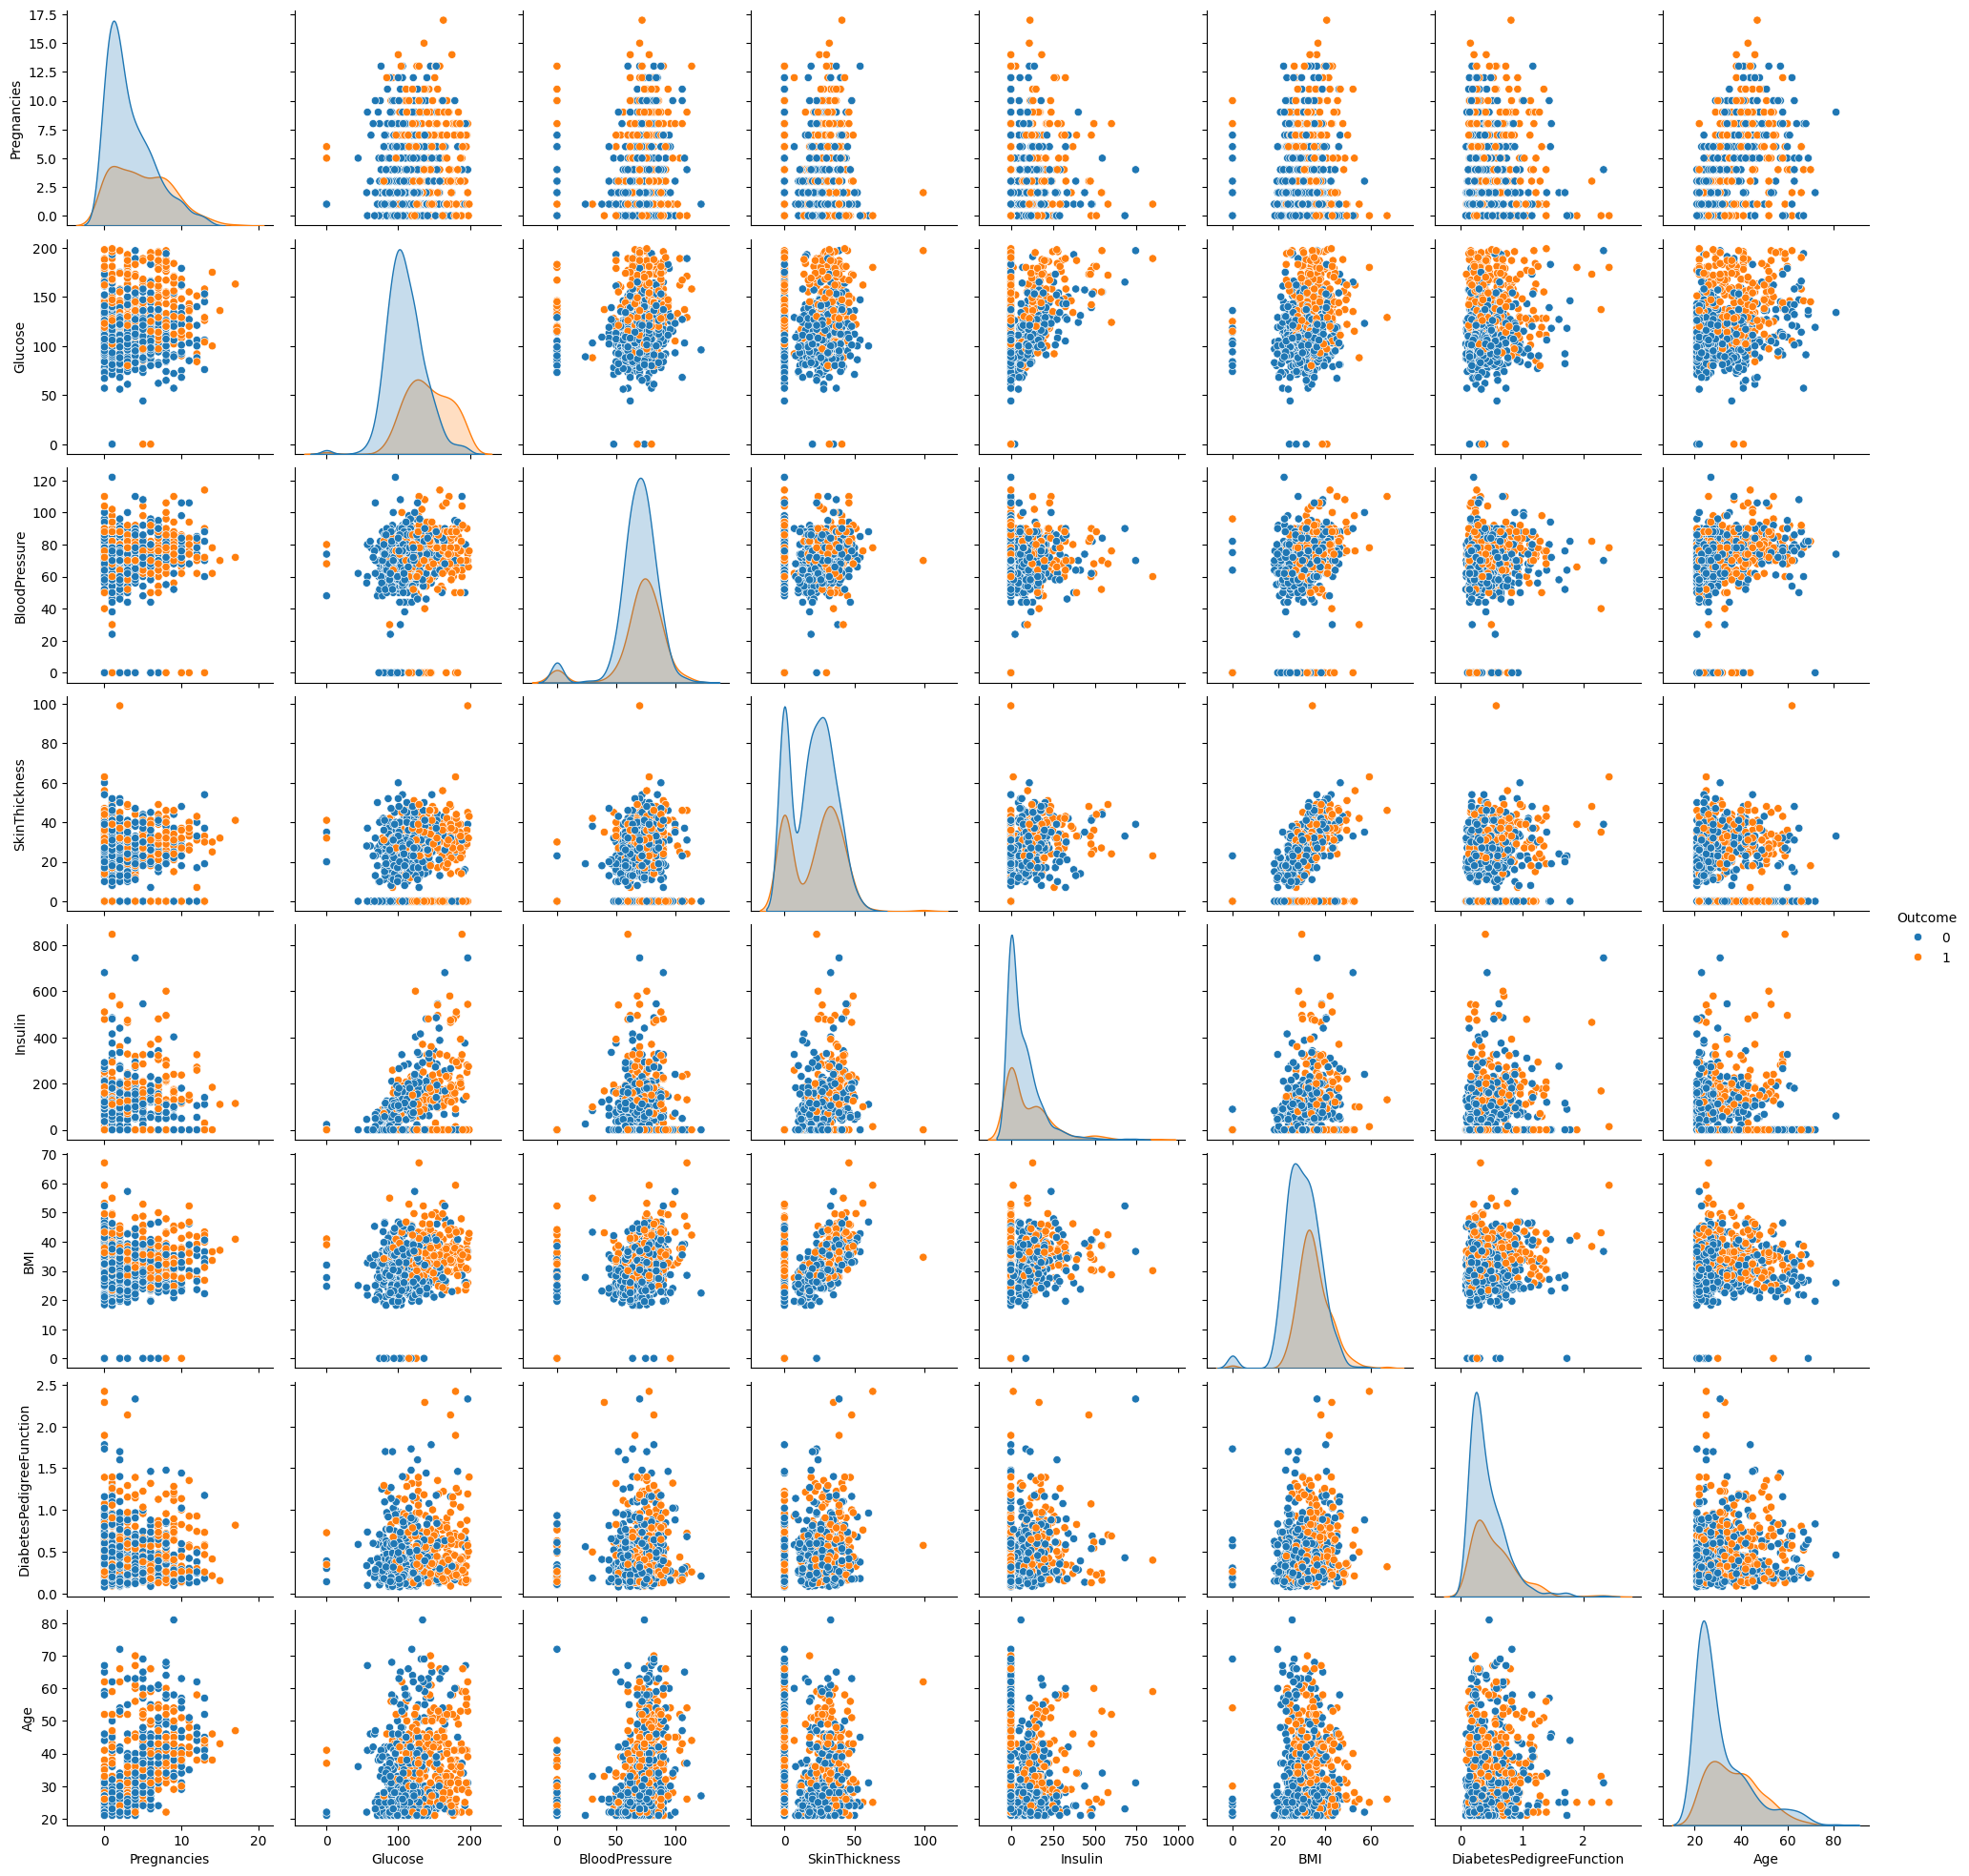

In [25]:
sns.pairplot(dia_df, hue="Outcome")

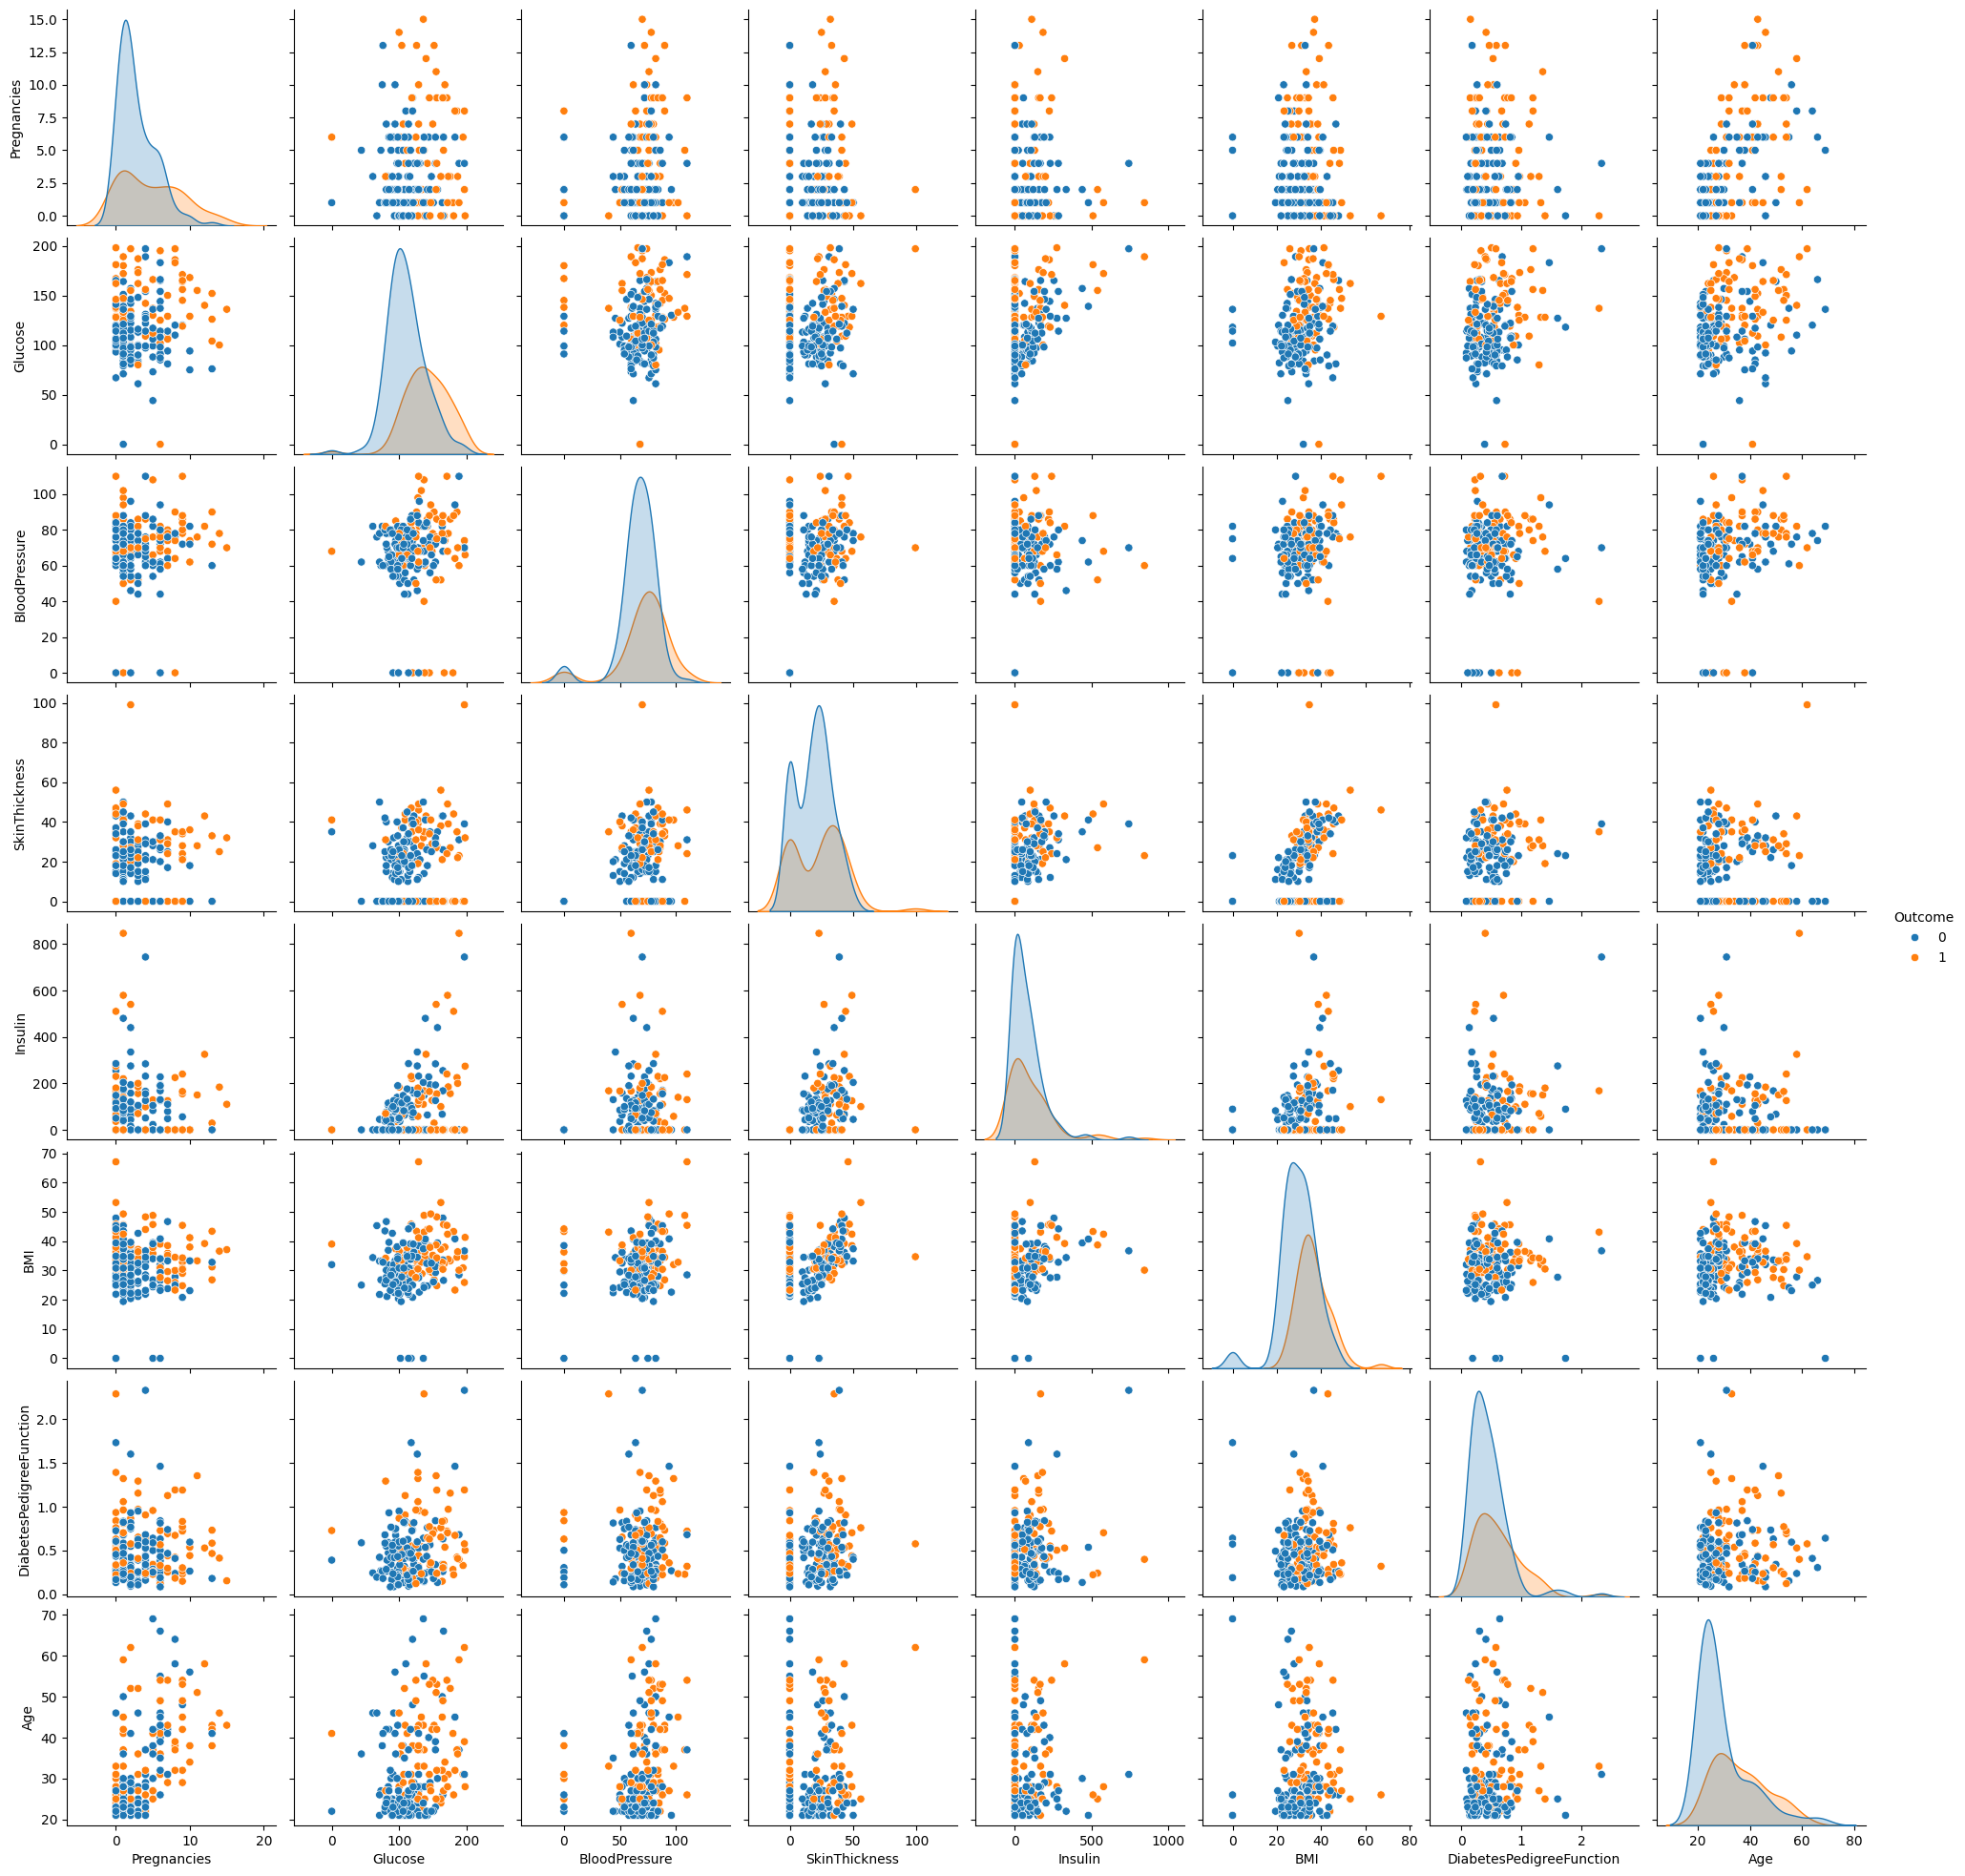

In [26]:
sns.pairplot(dia_df.sample(200), hue="Outcome")


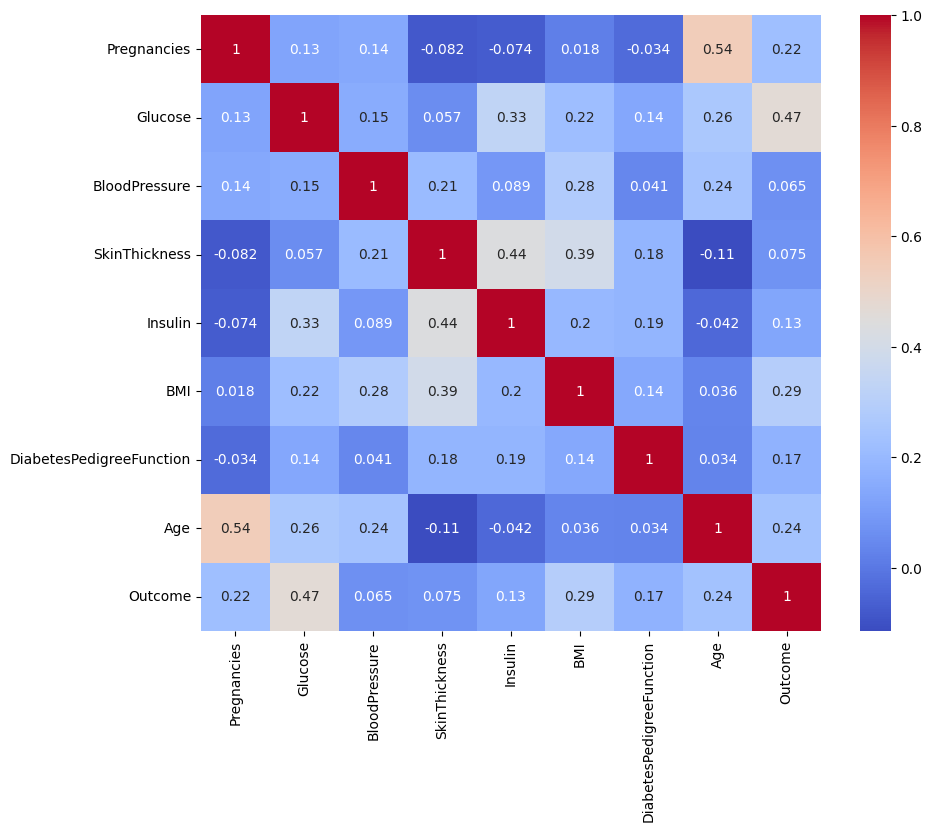

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(dia_df.corr(), annot=True, cmap='coolwarm')
plt.show()


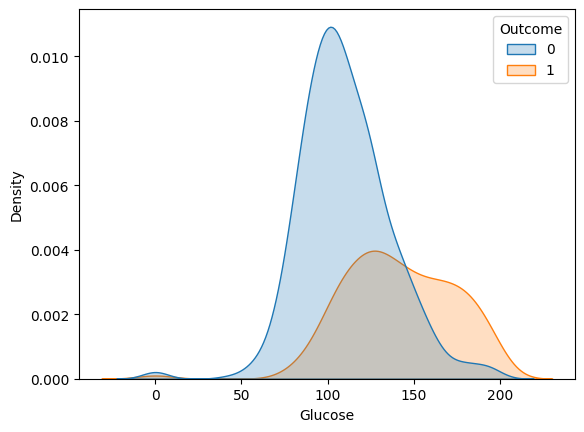

In [28]:
sns.kdeplot(data=dia_df, x="Glucose", hue="Outcome", fill=True)
plt.show()


In [29]:
corr=dia_df.corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

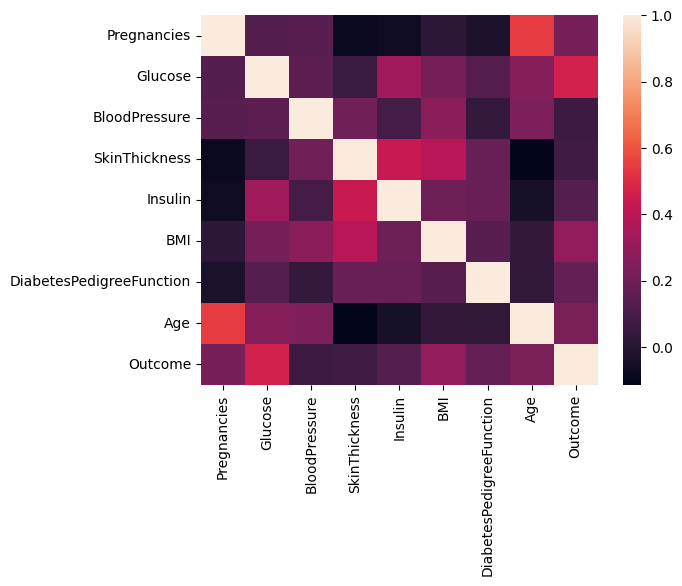

In [30]:
import seaborn as sns
sns.heatmap(corr,)

In [31]:
#separating the data and table
X = dia_df.drop('Outcome', axis=1)
Y = dia_df['Outcome']


In [32]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [33]:
Y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [35]:
Y_train.count()

np.int64(614)

In [36]:
Y_train.value_counts()

Outcome
0    400
1    214
Name: count, dtype: int64

In [37]:
Y_test.value_counts()

Outcome
0    100
1     54
Name: count, dtype: int64

In [38]:
X_train.head() #index randomly shuffle

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
619,0,119,0,0,0,32.4,0.141,24
329,6,105,70,32,68,30.8,0.122,37
13,1,189,60,23,846,30.1,0.398,59
476,2,105,80,45,191,33.7,0.711,29
45,0,180,66,39,0,42.0,1.893,25


In [39]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


In [40]:
from sklearn import svm

In [41]:
classifier = svm.SVC(kernel='linear')
classifier.fit(X_train, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [42]:
#Accuracy score on the training data
X_train_prediction=classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)


In [43]:
training_data_accuracy

0.7833876221498371

In [44]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# changing input data to numpy array
input_data_as_numpy_array = np.asarray(input_data)
print(input_data_as_numpy_array)

# reshape the array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
print(input_data_reshaped)
# prediction
prediction = classifier.predict(input_data_reshaped)

print(prediction)

if (prediction[0] == 0):
    print('The person is not diabetic')
else:
    print('The person is diabetic')



[  5.    166.     72.     19.    175.     25.8     0.587  51.   ]
[[  5.    166.     72.     19.    175.     25.8     0.587  51.   ]]
[1]
The person is diabetic


C:\Users\Nikita\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [45]:
for column in X.columns:
    print(column)

Pregnancies
Glucose
BloodPressure
SkinThickness
Insulin
BMI
DiabetesPedigreeFunction
Age


In [46]:
import os
import pickle

# folder create karo
os.makedirs("savedModels", exist_ok=True)

# model save karo
fileName = "savedModels/diabetes.sav"
pickle.dump(classifier, open(fileName, 'wb'))

print("Model saved successfully!")


Model saved successfully!


In [47]:
loaded_model = pickle.load(open(fileName, 'rb'))

In [48]:
input_data = (2,152,72,19,175,25.8,0.587,51)

#changing the input_data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are pridicting for one instance 
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction = loaded_model.predict(input_data_reshaped)


if (prediction[0] == 0):
    print("The person is not diabetic")
else:
    print("The person is diabetic")


The person is not diabetic


C:\Users\Nikita\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [51]:
import pickle
pickle.dump(classifier, open("diabetes.sav", "wb"))

In [55]:
import os
os.listdir()

['.ipynb_checkpoints',
 'diabetes.csv',
 'diabetes.sav',
 'dibaties.ipynb',
 'dibaties.sav',
 'heart.csv',
 'heart.sav',
 'heartdisease.ipynb',
 'parkinsons.csv',
 'parkisonsExploration.ipynb',
 'savedModels']